In [1]:
import random
import matplotlib.pyplot as plt
import numpy as np

In [2]:
num_days = 13
tickets_per_day = 3
free_ticket = 1
parts_for_extra_ticket = 4
items_on_wheel = 20

In [3]:
def wheel_sim():
    tickets = num_days * tickets_per_day + free_ticket
    ticket_parts = 0
    collected_prizes = set()

    while (tickets > 0):
        prize = random.randrange(0, items_on_wheel)
        if prize in collected_prizes:
            ticket_parts += 1
            if ticket_parts == 4:
                tickets += 1
                ticket_parts = 0
        else:
            collected_prizes.add(prize)
        tickets -= 1

    return len(collected_prizes)

In [4]:
num_trials = 100_000
all_trials = np.array([wheel_sim() for _ in range(0, num_trials)])

values, counts = np.unique(all_trials, return_counts=True)
probabilities = counts / num_trials

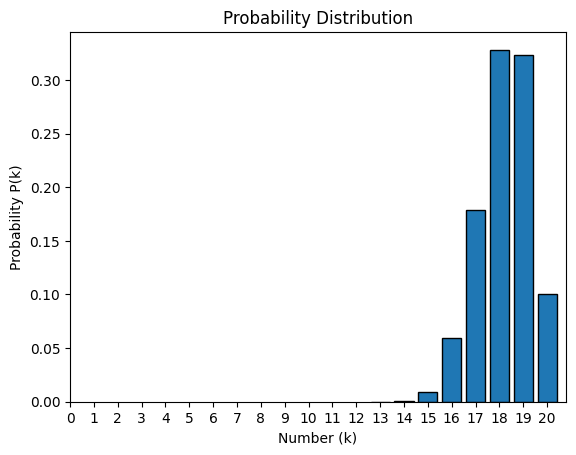

In [5]:
plt.bar(values, probabilities, width=0.8, edgecolor='black')
plt.xticks(np.arange(0, 21))
plt.xlabel("Number (k)")
plt.ylabel("Probability P(k)")
plt.title("Probability Distribution")
plt.show()

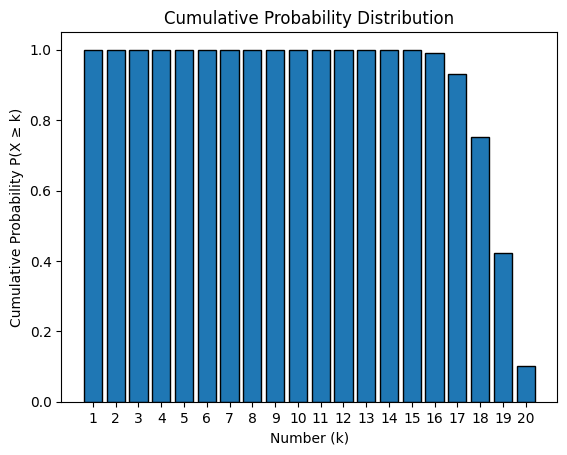

In [6]:
cumulative_probs = np.cumsum(probabilities[::-1])[::-1]

full_values = np.arange(1, 21)
full_cumulative_probs = np.array([cumulative_probs[values == v][0] if v in values else 1.0 for v in full_values])

plt.bar(full_values, full_cumulative_probs, width=0.8, edgecolor='black')

plt.xlabel("Number (k)")
plt.ylabel("Cumulative Probability P(X ≥ k)")
plt.title("Cumulative Probability Distribution")
plt.xticks(np.arange(1, 21))
plt.show()